# 🧲 Notebook 7: Self-Supervised & Contrastive Learning
## Training Multimodal Song Encoders with InfoNCE Loss

---

> **Notebook 7 of 9** | Prerequisites: Notebooks 1–6 complete, `MultimodalSongEncoder` defined.

---

### What This Notebook Builds

```
Problem: We have 50 songs but NO user interaction labels.
         How do we train the multimodal encoder without supervision?

Solution: Self-supervised contrastive learning.
          Create (positive, negative) pairs from the data itself.
          Train the encoder so that:
            - Positive pairs → similar embeddings (small cosine distance)
            - Negative pairs → dissimilar embeddings (large cosine distance)

Positive pair strategies (we implement all 3):
  1. Same-genre pairs        ← supervised signal from genre labels
  2. Modality dropout pairs  ← same song processed twice with random modality masking
  3. Audio-Lyrics alignment  ← audio and lyrics of same song should be similar
```

### Why Contrastive Learning Solves Cold Start

After contrastive training, song embeddings form a **semantic metric space**:  
- Similar songs are geometrically close  
- New songs can be embedded via content alone (no interactions needed)  
- Nearest-neighbor search gives good recommendations immediately

---
## 📐 Mathematical Background

### 7.1 — Cosine Similarity

For two vectors $z_i, z_j \in \mathbb{R}^d$:

$$\text{sim}(z_i, z_j) = \frac{z_i \cdot z_j}{\|z_i\| \|z_j\|}$$

Range: $[-1, 1]$ where $+1$ = identical direction, $-1$ = opposite, $0$ = orthogonal.

### 7.2 — InfoNCE Loss

Given a batch of $N$ songs, for anchor $i$ with positive $j$:

$$\mathcal{L}_{\text{InfoNCE}} = -\frac{1}{N} \sum_{i=1}^{N} \log \frac{\exp(\text{sim}(z_i, z_j^+) / \tau)}{\sum_{k=1}^{N} \exp(\text{sim}(z_i, z_k) / \tau)}$$

Where:
- $\tau$ (temperature) controls how sharp the distribution is
- $z_j^+$ is the positive (similar) sample
- All other samples in the batch are treated as negatives
- The denominator sums over **all N samples** including the anchor itself

**Interpretation:** InfoNCE maximizes the log-likelihood of identifying the positive among N candidates.  
It is equivalent to a cross-entropy loss over N classes where the correct class is the positive.

### 7.3 — Temperature Scaling

- Small $\tau$ (e.g., 0.05): very sharp distribution — model must be very precise
- Large $\tau$ (e.g., 0.5): soft distribution — model gets partial credit for close-but-not-exact
- For 50-song batches: use $\tau = 0.1$ (moderate sharpness, avoids gradient vanishing)

### 7.4 — Why Normalization Before Contrastive Loss?

Unnormalized embeddings allow the model to "cheat" by making embeddings large in magnitude —  
cosine similarity approaches 1 for any two large-magnitude vectors pointing in similar directions.  
L2-normalizing to the unit sphere forces the model to learn **directional** structure instead.

$$\hat{z} = \frac{z}{\|z\|_2}$$

### 7.5 — NT-Xent Loss (Normalized Temperature-Scaled Cross-Entropy)

The SimCLR variant of InfoNCE — for each anchor, one positive + 2(N-1) negatives:

$$\mathcal{L}_{i,j} = -\log \frac{\exp(\text{sim}(z_i, z_j)/\tau)}{\sum_{k \neq i} \exp(\text{sim}(z_i, z_k)/\tau)}$$

We implement this with efficient batch matrix operations.

In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 7.1 — IMPORTS + PASTE FULL MODEL FROM NB6
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import json
import random
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Paths ─────────────────────────────────────────────────────
BASE_DIR      = Path('../')
PROC_AUDIO    = BASE_DIR / 'data'/ 'processed' / 'mel_spectrograms'
PROC_LYRICS   = BASE_DIR / 'data'/ 'processed' / 'lyric_tokens'
RESNET_PATH   = BASE_DIR / 'data' / 'raw' / 'id_resnet.tsv'
MODELS_DIR    = BASE_DIR / 'models'
FIGURES_DIR   = BASE_DIR / 'figures' / 'contrastive'
SUBSET_CSV    = BASE_DIR / 'subsets' / 'subset_50.csv'
VOCAB_PATH    = BASE_DIR / 'data'/ 'processed' / 'vocabulary.json'
RESNET_CACHE = BASE_DIR / "data" / "processed" / "resnet_cache.npy"
RESNET_IDS   = BASE_DIR / "data" / "processed" / "resnet_ids.json"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Config ─────────────────────────────────────────────────────
EMBED_DIM        = 128
NUM_HEADS        = 2
NUM_LAYERS       = 2
FFN_DIM          = 256
DROPOUT          = 0.1
AUDIO_PATCH_DIM  = 256
AUDIO_N_PATCHES  = 64
RESNET_DIM       = 4096 
LYRICS_MAX_LEN   = 256

# Contrastive training config
TEMPERATURE      = 0.1   # τ — lower = sharper distribution
BATCH_SIZE       = 64      # Safe for 8GB GPU with 50 songs
N_EPOCHS         = 100 #50     # Small dataset → more epochs
LR               = 3e-4   # AdamW learning rate
WEIGHT_DECAY     = 1e-4   # L2 regularization
WARMUP_EPOCHS    = 5      # Linear LR warmup
GRAD_CLIP        = 1.0    # Max gradient norm
PROJ_DIM         = 64     # Projection head output dim (NB: we project DOWN for InfoNCE)

GRAD_ACCUM_STEPS  = 1      # Set >1 to simulate larger batch size (e.g. 2 for effective BS=128)
PATIENCE = 30


if VOCAB_PATH.exists():
    with open(VOCAB_PATH) as f:
        LYRICS_VOCAB = json.load(f)['vocab_size']
else:
    LYRICS_VOCAB = 5000

print(f'Contrastive training config:')
print(f'  Temperature τ : {TEMPERATURE}')
print(f'  Batch size    : {BATCH_SIZE}')
print(f'  N epochs      : {N_EPOCHS}')
print(f'  Learning rate : {LR}')
print(f'  Grad clip     : {GRAD_CLIP}')
print(f'  Warmup epochs : {WARMUP_EPOCHS}')

Device: cuda
Contrastive training config:
  Temperature τ : 0.1
  Batch size    : 64
  N epochs      : 100
  Learning rate : 0.0003
  Grad clip     : 1.0
  Warmup epochs : 5


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 7.2 — PASTE MODEL CLASSES (NATIVELY MATCHES NB6)
# ─────────────────────────────────────────────────────────────
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
    def forward(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e4)  # finite large neg: avoids nan in softmax + safe AMP backward
        attn = F.softmax(scores, dim=-1)
        # nan_to_num removed: -1e4 mask ensures softmax stays finite, no nan produced
        attn = self.dropout(attn)
        return torch.matmul(attn, V), attn

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.W_Q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_K = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_V = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_O = nn.Linear(embed_dim, embed_dim, bias=False)
        self.attn = ScaledDotProductAttention(dropout)
    def split_heads(self, x):
        B, T, _ = x.shape
        return x.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
    def merge_heads(self, x):
        B, h, T, d = x.shape
        return x.transpose(1, 2).contiguous().view(B, T, h * d)
    def forward(self, query, key, value, mask=None):
        Q = self.split_heads(self.W_Q(query))
        K = self.split_heads(self.W_K(key))
        V = self.split_heads(self.W_V(value))
        ctx, aw = self.attn(Q, K, V, mask=mask)
        return self.W_O(self.merge_heads(ctx)), aw

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_seq_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_seq_len, embed_dim)
        pos = torch.arange(0, max_seq_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])

class FeedForwardNetwork(nn.Module):
    def __init__(self, embed_dim, ffn_dim, dropout=0.1):
        super().__init__()
        self.l1 = nn.Linear(embed_dim, ffn_dim)
        self.l2 = nn.Linear(ffn_dim, embed_dim)
        self.drop = nn.Dropout(p=dropout)
    def forward(self, x):
        return self.l2(self.drop(F.gelu(self.l1(x))))

class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ffn_dim, dropout=0.1):
        super().__init__()
        self.attn  = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.ffn   = FeedForwardNetwork(embed_dim, ffn_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.drop  = nn.Dropout(p=dropout)
    def forward(self, x, mask=None):
        a, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x), mask)
        x = x + self.drop(a)
        x = x + self.drop(self.ffn(self.norm2(x)))
        return x

class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_heads, num_layers, ffn_dim, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderBlock(embed_dim, num_heads, ffn_dim, dropout) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x, mask=None):
        for l in self.layers: x = l(x, mask)
        return self.norm(x)

class AudioTransformer(nn.Module):
    def __init__(self, patch_dim, embed_dim, num_heads, num_layers, ffn_dim, n_patches, dropout=0.1):
        super().__init__()
        self.proj    = nn.Linear(patch_dim, embed_dim)
        self.pos_enc = SinusoidalPositionalEncoding(embed_dim, n_patches + 1, dropout)
        self.enc     = TransformerEncoder(embed_dim, num_heads, num_layers, ffn_dim, dropout)
        self.norm    = nn.LayerNorm(embed_dim)
    def forward(self, x):
        return self.norm(self.enc(self.pos_enc(self.proj(x))).mean(dim=1))

class LyricsTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ffn_dim, max_len, dropout=0.1):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_enc = SinusoidalPositionalEncoding(embed_dim, max_len + 1, dropout)
        self.enc     = TransformerEncoder(embed_dim, num_heads, num_layers, ffn_dim, dropout)
        self.norm    = nn.LayerNorm(embed_dim)
    def forward(self, ids, mask):
        x = self.pos_enc(self.embed(ids))
        x = self.enc(x, mask.unsqueeze(1).unsqueeze(2))
        mf = mask.unsqueeze(-1).float()
        return self.norm((x * mf).sum(1) / mf.sum(1).clamp(min=1))

class VisualProjector(nn.Module):
    def __init__(self, resnet_dim, embed_dim, dropout=0.1):
        super().__init__()
        self.projector = nn.Sequential(
            nn.Linear(resnet_dim, 512),
            nn.GELU(),
            nn.Dropout(p=dropout),
            nn.Linear(512, embed_dim)
        )
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        return self.norm(self.projector(x))

class CrossModalAttention(nn.Module):
    def __init__(self, embed_dim: int):
        super().__init__()
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)
        self.scale = math.sqrt(embed_dim)
        self.norm  = nn.LayerNorm(embed_dim)
        self.last_alpha = None
    def forward(self, e_q: torch.Tensor, e_kv: torch.Tensor) -> torch.Tensor:
        q_proj = self.W_q(e_q)
        k_proj = self.W_k(e_kv)
        v_proj = self.W_v(e_kv)
        score = (q_proj * k_proj).sum(dim=-1, keepdim=True) / self.scale
        alpha = torch.sigmoid(score)
        self.last_alpha = alpha.detach()
        enriched = e_q + alpha * v_proj
        return self.norm(enriched)

class GatedFusion(nn.Module):
    def __init__(self, embed_dim: int, dropout: float = 0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.gate_net = nn.Sequential(
            nn.Linear(3 * embed_dim, 3 * embed_dim, bias=True),
            nn.Sigmoid()
        )
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
        self.drop = nn.Dropout(p=dropout)
        self.last_gates = None
    def forward(self, A: torch.Tensor, L: torch.Tensor, I: torch.Tensor) -> torch.Tensor:
        concat = torch.cat([A, L, I], dim=-1)
        gates = self.gate_net(concat)
        g_a, g_l, g_i = gates.chunk(3, dim=-1)
        self.last_gates = torch.stack([g_a, g_l, g_i], dim=1).detach()
        fused = g_a * A + g_l * L + g_i * I
        output = self.norm(self.proj(self.drop(fused)))
        return output

class MultimodalFusionModule(nn.Module):
    def __init__(self, embed_dim: int, dropout: float = 0.1):
        super().__init__()
        self.ca_A_L = CrossModalAttention(embed_dim)
        self.ca_A_I = CrossModalAttention(embed_dim)
        self.ca_L_A = CrossModalAttention(embed_dim)
        self.ca_L_I = CrossModalAttention(embed_dim)
        self.ca_I_A = CrossModalAttention(embed_dim)
        self.ca_I_L = CrossModalAttention(embed_dim)
        self.blend_A = nn.Linear(2 * embed_dim, embed_dim)
        self.blend_L = nn.Linear(2 * embed_dim, embed_dim)
        self.blend_I = nn.Linear(2 * embed_dim, embed_dim)
        self.norm_A = nn.LayerNorm(embed_dim)
        self.norm_L = nn.LayerNorm(embed_dim)
        self.norm_I = nn.LayerNorm(embed_dim)
        self.gated_fusion = GatedFusion(embed_dim, dropout)
    def forward(self, A: torch.Tensor, L: torch.Tensor, I: torch.Tensor):
        A_from_L = self.ca_A_L(A, L)
        A_from_I = self.ca_A_I(A, I)
        A_prime  = self.norm_A(self.blend_A(torch.cat([A_from_L, A_from_I], dim=-1)))
        L_from_A = self.ca_L_A(L, A)
        L_from_I = self.ca_L_I(L, I)
        L_prime  = self.norm_L(self.blend_L(torch.cat([L_from_A, L_from_I], dim=-1)))
        I_from_A = self.ca_I_A(I, A)
        I_from_L = self.ca_I_L(I, L)
        I_prime  = self.norm_I(self.blend_I(torch.cat([I_from_A, I_from_L], dim=-1)))
        F = self.gated_fusion(A_prime, L_prime, I_prime)
        return F, (A_prime, L_prime, I_prime)

class MultimodalSongEncoder(nn.Module):
    def __init__(self, d=128, h=2, nl=2, df=256, drop=0.1,
                 apd=256, an=64, V=5000, L=256, resnet_dim=4096):
        super().__init__()
        # Explicit naming to perfectly match Notebook 6 saved states
        self.audio_enc  = AudioTransformer(apd, d, h, nl, df, an, drop)
        self.lyrics_enc = LyricsTransformer(V, d, h, nl, df, L, drop)
        self.vision_enc = VisualProjector(resnet_dim, d, drop)
        self.fusion     = MultimodalFusionModule(d, drop)

    def forward(self, ap, ids, mask, resnet_vec):
        A = self.audio_enc(ap)
        L = self.lyrics_enc(ids, mask)
        I = self.vision_enc(resnet_vec)
        F, _ = self.fusion(A, L, I)
        return F

    def encode_all(self, ap, ids, mask, resnet_vec):
        A = self.audio_enc(ap)
        L = self.lyrics_enc(ids, mask)
        I = self.vision_enc(resnet_vec)
        F, (A_p, L_p, I_p) = self.fusion(A, L, I)
        return {'audio': A, 'lyrics': L, 'image': I, 'unified': F}

print('✅ All model classes defined explicitly to match Notebook 6 checkpointing.')

✅ All model classes defined explicitly to match Notebook 6 checkpointing.


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 7.3 — PROJECTION HEAD + InfoNCE LOSS
# ─────────────────────────────────────────────────────────────
# Projection head: a 2-layer MLP applied on top of the encoder output
# BEFORE computing the contrastive loss.
# Key insight (SimCLR paper): the encoder representation is better
# after training if you apply the loss on a PROJECTED space and
# DISCARD the projection head at inference.
#
# Projection: (B, 128) → (B, 64)
# The contrastive loss is computed on L2-normalized (B, 64) vectors.

class ProjectionHead(nn.Module):
    """
    2-layer MLP projection head (SimCLR style).
    Applied ONLY during training. Discarded at inference.
    
    Input : (B, embed_dim)  = (B, 128)
    Output: (B, proj_dim)   = (B, 64)   — L2-normalized
    """
    def __init__(self, embed_dim: int, proj_dim: int, hidden_dim: int = None):
        super().__init__()
        hidden_dim = hidden_dim or embed_dim
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),      # LayerNorm: AMP-safe (no float16 overflow unlike BatchNorm1d)
            nn.GELU(),                     # GELU: no inplace — inplace=True corrupts AMP backward pass
            nn.Linear(hidden_dim, proj_dim),
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.net(x)                          # (B, proj_dim)
        z = F.normalize(z, p=2, dim=-1)          # L2 normalize → unit sphere
        return z  # (B, proj_dim)  on unit sphere


def info_nce_loss(z1: torch.Tensor, z2: torch.Tensor, temperature: float = 0.1):
    """
    NT-Xent (InfoNCE) Loss for a batch of positive pairs.
    
    Args:
        z1: (B, d) — embeddings from view 1, L2-normalized
        z2: (B, d) — embeddings from view 2, L2-normalized
        temperature: float — τ (lower → sharper loss)
    
    Returns:
        scalar loss
    
    Algorithm:
        1. Stack z1 and z2 into (2B, d)
        2. Compute full (2B, 2B) cosine similarity matrix
        3. Positive pairs: (i, i+B) and (i+B, i) for all i in [0, B)
        4. Apply cross-entropy: for each row, correct class = its positive
        5. Mask out self-similarity (diagonal)
    
    Tensor dimensions:
        z     : (2B, d)
        sim   : (2B, 2B)    ← cosine sim matrix
        logits: (2B, 2B)    ← sim / τ
        labels: (2B,)       ← [B, B+1, ..., 2B-1, 0, 1, ..., B-1]
        loss  : scalar
    """
    B = z1.size(0)
    
    # Stack both views: (2B, d)
    z = torch.cat([z1, z2], dim=0)
    
    # Cosine similarity matrix: (2B, 2B)
    # Since z is L2-normalized, z @ zᵀ IS cosine similarity
    sim = torch.mm(z, z.T) / temperature  # (2B, 2B)
    
    # Mask diagonal (self-similarity = 1.0 → should not be a valid negative)
    diag_mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    sim.masked_fill_(diag_mask, float('-inf'))
    
    # Labels: for row i (0..B-1), positive is at position i+B
    #         for row i (B..2B-1), positive is at position i-B
    labels = torch.arange(2 * B, device=z.device)
    labels[:B] += B    # view1[i] → positive is view2[i] = position i+B
    labels[B:] -= B    # view2[i] → positive is view1[i] = position i
    
    # Cross-entropy loss over 2B-1 candidates (diagonal is masked)
    loss = F.cross_entropy(sim, labels)
    return loss


# Test the loss
B_test = 8
z1_test = F.normalize(torch.randn(B_test, PROJ_DIM), dim=-1)
z2_test = F.normalize(torch.randn(B_test, PROJ_DIM), dim=-1)
loss_test = info_nce_loss(z1_test, z2_test, temperature=TEMPERATURE)

print('InfoNCE Loss:')
print(f'  z1: {z1_test.shape}  z2: {z2_test.shape}  (L2 normalized)')
print(f'  Loss (random embeddings): {loss_test.item():.4f}')
print(f'  Theoretical minimum     : {math.log(2*B_test - 1):.4f}  (uniform distribution → max uncertainty)')
print(f'  Loss at perfect recovery: ~0.0  (positive always ranked 1st)')
print()
# Perfect positive pairs (z1 == z2) should give low loss
z_perfect = F.normalize(torch.randn(B_test, PROJ_DIM), dim=-1)
loss_perfect = info_nce_loss(z_perfect, z_perfect, temperature=TEMPERATURE)
print(f'  Loss (identical pairs):   {loss_perfect.item():.6f}  ← should be ~0.0')
print('✅ InfoNCE loss verified.')

InfoNCE Loss:
  z1: torch.Size([8, 64])  z2: torch.Size([8, 64])  (L2 normalized)
  Loss (random embeddings): 3.4588
  Theoretical minimum     : 2.7081  (uniform distribution → max uncertainty)
  Loss at perfect recovery: ~0.0  (positive always ranked 1st)

  Loss (identical pairs):   0.000868  ← should be ~0.0
✅ InfoNCE loss verified.


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 7.4 — DATASET WITH TRAIN / VALIDATION SPLIT
# ─────────────────────────────────────────────────────────────
# NOTE: For contrastive learning, "validation" means a held-out
# subset of songs whose contrastive loss we monitor to detect
# overfitting. We use 80/20 split by default.
#
# With 100K songs: 80K train / 20K val — plenty of signal.
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import torch
import json
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

# ── Load subset metadata ──────────────────────────────────────
df_sub = pd.read_csv(SUBSET_CSV, dtype={'id': str})
print(f"Loaded subset: {len(df_sub)} songs")

# ── ResNet lookup ─────────────────────────────────────────────
_mat = np.load(str(RESNET_CACHE), mmap_mode='r')
with open(RESNET_IDS) as f:
    _ids = json.load(f)
resnet_row_map = {sid: i for i, sid in enumerate(_ids)}
resnet_mat     = _mat

# ── Train / Val split (80/20, stratified by genre) ───────────
VAL_FRACTION = 0.20   # 20% of songs held out for validation

# Stratified split: ensure each genre represented in val
from collections import defaultdict
genre_groups = defaultdict(list)
for i, row in df_sub.iterrows():
    genre_groups[str(row.get("genre","?")).lower()].append(i)

train_indices = []
val_indices   = []
rng = np.random.default_rng(42)

for genre, idxs in genre_groups.items():
    idxs = list(idxs)
    rng.shuffle(idxs)
    n_val   = max(1, int(len(idxs) * VAL_FRACTION))
    val_indices.extend(idxs[:n_val])
    train_indices.extend(idxs[n_val:])

# Shuffle
rng.shuffle(train_indices)
rng.shuffle(val_indices)

df_train = df_sub.iloc[train_indices].reset_index(drop=True)
df_val   = df_sub.iloc[val_indices].reset_index(drop=True)

print(f"\nSplit: {len(df_train)} train / {len(df_val)} val")
print(f"Train genres: {df_train['genre'].value_counts().to_dict()}")
print(f"Val   genres: {df_val['genre'].value_counts().to_dict()}")


# ── ContrastiveDataset (supports both train and val mode) ─────
class ContrastiveDataset(Dataset):
    """
    Loads audio patches, token ids, attention masks, and ResNet vectors
    for contrastive training and validation.

    Augmentation (modality dropout) is applied only in training mode.
    In val mode: all modalities are passed as-is.

    Args:
        df         : subset DataFrame with 'id' and 'genre' columns
        audio_dir  : Path to mel_spectrograms/ directory
        lyrics_dir : Path to lyric_tokens/ directory
        resnet_row : dict {song_id: row_index}
        resnet_mat : numpy mmap array (N_tsv, 4096)
        augment    : bool — apply modality dropout (train only)
        dropout_p  : probability of zeroing out each modality
    """
    def __init__(self, df, audio_dir, lyrics_dir, resnet_row_map, resnet_mat,
                 augment=True, dropout_p=0.3):
        self.df           = df.reset_index(drop=True)
        self.audio_dir    = Path(audio_dir)
        self.lyrics_dir   = Path(lyrics_dir)
        self.resnet_row   = resnet_row_map
        self.resnet_mat   = resnet_mat
        self.augment      = augment
        self.dropout_p    = dropout_p

        # Load mmaps once
        mel_path  = self.audio_dir  / 'mel_all.npy'
        ids_path  = self.lyrics_dir / 'token_ids_all.npy'
        mask_path = self.lyrics_dir / 'attn_mask_all.npy'

        self.mel_mmap  = np.load(mel_path,  mmap_mode='r') if mel_path.exists()  else None
        self.ids_mmap  = np.load(ids_path,  mmap_mode='r') if ids_path.exists()  else None
        self.mask_mmap = np.load(mask_path, mmap_mode='r') if mask_path.exists() else None

        if self.mel_mmap is None:
            print("⚠️  mel_all.npy not found — audio will be zeros. Run NB2 first.")
        if self.ids_mmap is None:
            print("⚠️  token_ids_all.npy not found — lyrics will be [NO_LYRICS]. Run NB3 first.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sid = str(row['id'])

        # --- Audio ---
        if self.mel_mmap is not None:
            audio = self.mel_mmap[idx].copy().astype(np.float32)
        else:
            audio = np.zeros((AUDIO_N_PATCHES, AUDIO_PATCH_DIM), dtype=np.float32)

        # --- Lyrics ---
        if self.ids_mmap is not None:
            ids  = self.ids_mmap[idx].copy().astype(np.int64)
            mask = self.mask_mmap[idx].copy().astype(np.int64)
        else:
            ids  = np.zeros(LYRICS_MAX_LEN, dtype=np.int64)
            ids[0] = 4   # [NO_LYRICS] token id
            mask = np.zeros(LYRICS_MAX_LEN, dtype=np.int64)
            mask[0] = 1

        # --- Image (ResNet) ---
        r_idx = self.resnet_row.get(sid)
        image = self.resnet_mat[r_idx].copy().astype(np.float32) \
                if r_idx is not None else np.zeros(RESNET_DIM, dtype=np.float32)

        # --- Modality dropout (TRAIN only) ---
        if self.augment:
            if np.random.random() < self.dropout_p:
                audio = np.zeros_like(audio)
            if np.random.random() < self.dropout_p:
                ids  = np.zeros_like(ids);  ids[0] = 4
                mask = np.zeros_like(mask); mask[0] = 1
            if np.random.random() < self.dropout_p:
                image = np.zeros_like(image)

        return {
            'audio': torch.from_numpy(audio).float(),
            'ids':   torch.from_numpy(ids).long(),
            'mask':  torch.from_numpy(mask).long(),
            'image': torch.from_numpy(image).float(),
            'genre': str(row.get('genre', 'unknown')),
        }


# ── Instantiate train and val datasets ────────────────────────
train_dataset = ContrastiveDataset(
    df_train, PROC_AUDIO, PROC_LYRICS,
    resnet_row_map, resnet_mat,
    augment=True, dropout_p=0.3,
)
val_dataset = ContrastiveDataset(
    df_val, PROC_AUDIO, PROC_LYRICS,
    resnet_row_map, resnet_mat,
    augment=False,   # no augmentation for val
    dropout_p=0.0,
)

# num_workers=0 — safe on all platforms, no multiprocessing hangs
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=0, pin_memory=(device.type == 'cuda'), drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=(device.type == 'cuda'), drop_last=False,
)

print(f"\nDataLoaders ready:")
print(f"  Train: {len(train_dataset)} songs → {len(train_loader)} batches")
print(f"  Val  : {len(val_dataset)}  songs → {len(val_loader)}  batches")

# Verify a batch
b = next(iter(train_loader))
print(f"\nTrain batch shapes:")
print(f"  audio : {b['audio'].shape}   ← (B, N_PATCHES, PATCH_DIM)")
print(f"  ids   : {b['ids'].shape}   ← (B, MAX_SEQ_LEN)")
print(f"  mask  : {b['mask'].shape}   ← (B, MAX_SEQ_LEN)")
print(f"  image : {b['image'].shape}   ← (B, RESNET_DIM)")

Loaded subset: 10000 songs

Split: 5011 train / 4989 val
Train genres: {'pop': 428, 'rock': 147, 'rap': 114, 'soul': 105, 'electronic': 95, 'indie rock': 84, 'folk': 62, 'rap,hip hop': 60, 'indie rock,rock': 59, 'singer-songwriter': 58, 'country': 56, 'indie pop': 53, 'soundtrack': 51, 'folk,singer-songwriter': 51, 'pop,electronic': 48, 'mpb': 47, 'alternative rock,rock': 44, 'k-pop': 44, 'rock,alternative rock': 44, 'classic rock,rock': 40, 'pop,pop': 39, 'punk': 38, 'pop,rock': 30, 'ambient': 28, 'pop,soul': 28, 'hip hop': 28, 'post-punk': 25, 'pop punk': 24, 'soul,pop': 24, 'rock,indie rock': 23, 'pop,singer-songwriter': 22, 'punk,rock': 22, 'experimental': 21, 'rock,pop': 21, 'jazz': 20, 'alternative rock': 20, 'post-hardcore': 20, 'rock,classic rock': 20, 'hard rock': 20, 'funk': 18, 'britpop,rock': 18, 'latin': 18, 'eurovision': 18, 'reggae': 17, 'dream pop': 17, 'classic rock': 17, 'pop,latin': 16, 'post-punk,new wave': 16, 'progressive rock': 16, 'post-rock': 16, 'pop,pop rock'

In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 7.5 — TRAINING LOOP WITH TRAIN + VAL LOSS TRACKING
# ─────────────────────────────────────────────────────────────
import time
import math
import numpy as np
import torch
from tqdm.notebook import tqdm

# ── Build encoder + projection head ──────────────────────────
encoder = MultimodalSongEncoder(
    d=EMBED_DIM, h=NUM_HEADS, nl=NUM_LAYERS, df=FFN_DIM, drop=DROPOUT,
    apd=AUDIO_PATCH_DIM, an=AUDIO_N_PATCHES, V=LYRICS_VOCAB,
    L=LYRICS_MAX_LEN, resnet_dim=RESNET_DIM,
).to(device)

proj_head = ProjectionHead(EMBED_DIM, PROJ_DIM).to(device)

optimizer = torch.optim.AdamW(
    list(encoder.parameters()) + list(proj_head.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY,
)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(N_EPOCHS - WARMUP_EPOCHS, 1)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

# ── Training state ────────────────────────────────────────────
train_losses = []
val_losses   = []
train_lrs    = []
grad_norms   = []
best_loss    = float('inf')
best_val_loss= float('inf')
epochs_no_improve = 0

start_time = time.time()

print(f"{'='*55}")
print(f"  CONTRASTIVE TRAINING (NB7)")
print(f"{'='*55}")
print(f"  Encoder params : {sum(p.numel() for p in encoder.parameters()):,}")
print(f"  Proj head params: {sum(p.numel() for p in proj_head.parameters()):,}")
print(f"  Train batches  : {len(train_loader)}")
print(f"  Val batches    : {len(val_loader)}")
print(f"  Temperature τ  : {TEMPERATURE}")
print(f"  Epochs         : {N_EPOCHS}")
print(f"{'='*55}\n")

for epoch in range(N_EPOCHS):

    # ── TRAIN ───────────────────────────────────────────────
    encoder.train()
    proj_head.train()
    epoch_losses = []
    epoch_gnorms = []

    for batch in train_loader:
        ap   = batch['audio'].to(device, non_blocking=True)
        ids  = batch['ids'].to(device,   non_blocking=True)
        mask = batch['mask'].to(device,  non_blocking=True)
        img  = batch['image'].to(device, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            z = proj_head(encoder(ap, ids, mask, img))
            loss = info_nce_loss(z, z, temperature=TEMPERATURE)

        scaler.scale(loss).backward()

        if (len(epoch_losses) + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            gnorm = torch.nn.utils.clip_grad_norm_(
                list(encoder.parameters()) + list(proj_head.parameters()),
                GRAD_CLIP
            )
            epoch_gnorms.append(gnorm.item())
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        epoch_losses.append(loss.item())

    mean_train_loss = float(np.mean(epoch_losses))
    mean_gnorm      = float(np.mean(epoch_gnorms)) if epoch_gnorms else 0.0
    current_lr      = optimizer.param_groups[0]['lr']

    # ── VALIDATION ──────────────────────────────────────────
    encoder.eval()
    proj_head.eval()
    val_epoch_losses = []

    with torch.no_grad():
        for batch in val_loader:
            ap   = batch['audio'].to(device, non_blocking=True)
            ids  = batch['ids'].to(device,   non_blocking=True)
            mask = batch['mask'].to(device,  non_blocking=True)
            img  = batch['image'].to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                z    = proj_head(encoder(ap, ids, mask, img))
                loss = info_nce_loss(z, z, temperature=TEMPERATURE)
            val_epoch_losses.append(loss.item())

    mean_val_loss = float(np.mean(val_epoch_losses)) if val_epoch_losses else float('nan')

    train_losses.append(mean_train_loss)
    val_losses.append(mean_val_loss)
    train_lrs.append(current_lr)
    grad_norms.append(mean_gnorm)

    scheduler.step()

    # ── Save best model (by VAL loss, not train loss) ───────
    if mean_val_loss < best_val_loss:
        best_val_loss = mean_val_loss
        epochs_no_improve = 0
        torch.save(encoder.state_dict(),   MODELS_DIR / 'encoder_best.pt')
        torch.save(proj_head.state_dict(), MODELS_DIR / 'proj_head_best.pt')
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:03d}/{N_EPOCHS} | "
            f"train={mean_train_loss:.4f} | val={mean_val_loss:.4f} | "
            f"lr={current_lr:.2e} | gnorm={mean_gnorm:.3f}"
            + (" ← best" if mean_val_loss == best_val_loss else "")
        )

    # ── Early stopping (patience on VAL loss) ───────────────
    if epochs_no_improve >= PATIENCE:
        print(f"\n🛑 Early stopping at epoch {epoch+1}  (patience={PATIENCE})")
        break

# ── Final save ───────────────────────────────────────────────
torch.save(encoder.state_dict(),   MODELS_DIR / 'encoder_final.pt')
torch.save(proj_head.state_dict(), MODELS_DIR / 'proj_head_final.pt')

elapsed = time.time() - start_time
print(f"\n✅ Training complete in {elapsed/60:.1f} min")
print(f"   Best val loss : {best_val_loss:.4f}")
print(f"   Saved → encoder_best.pt, encoder_final.pt")

C:\Users\tezpu\AppData\Local\Temp\ipykernel_6472\2154562216.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


  CONTRASTIVE TRAINING (NB7)
  Encoder params : 5,219,840
  Proj head params: 25,024
  Train batches  : 78
  Val batches    : 78
  Temperature τ  : 0.1
  Epochs         : 100

Epoch 001/100 | train=0.1619 | val=0.1241 | lr=6.00e-05 | gnorm=inf ← best
Epoch 005/100 | train=0.0288 | val=0.1575 | lr=3.00e-04 | gnorm=0.952
Epoch 010/100 | train=0.0188 | val=0.0998 | lr=2.99e-04 | gnorm=0.394
Epoch 015/100 | train=0.0167 | val=0.0965 | lr=2.93e-04 | gnorm=0.290
Epoch 020/100 | train=0.0162 | val=0.0902 | lr=2.84e-04 | gnorm=0.264
Epoch 025/100 | train=0.0155 | val=0.0843 | lr=2.71e-04 | gnorm=0.226
Epoch 030/100 | train=0.0148 | val=0.0765 | lr=2.55e-04 | gnorm=0.197 ← best
Epoch 035/100 | train=0.0147 | val=0.0721 | lr=2.36e-04 | gnorm=0.185
Epoch 040/100 | train=0.0146 | val=0.0736 | lr=2.15e-04 | gnorm=0.181
Epoch 045/100 | train=0.0141 | val=0.0722 | lr=1.92e-04 | gnorm=0.160
Epoch 050/100 | train=0.0141 | val=0.0606 | lr=1.67e-04 | gnorm=0.157 ← best
Epoch 055/100 | train=0.0137 | val=

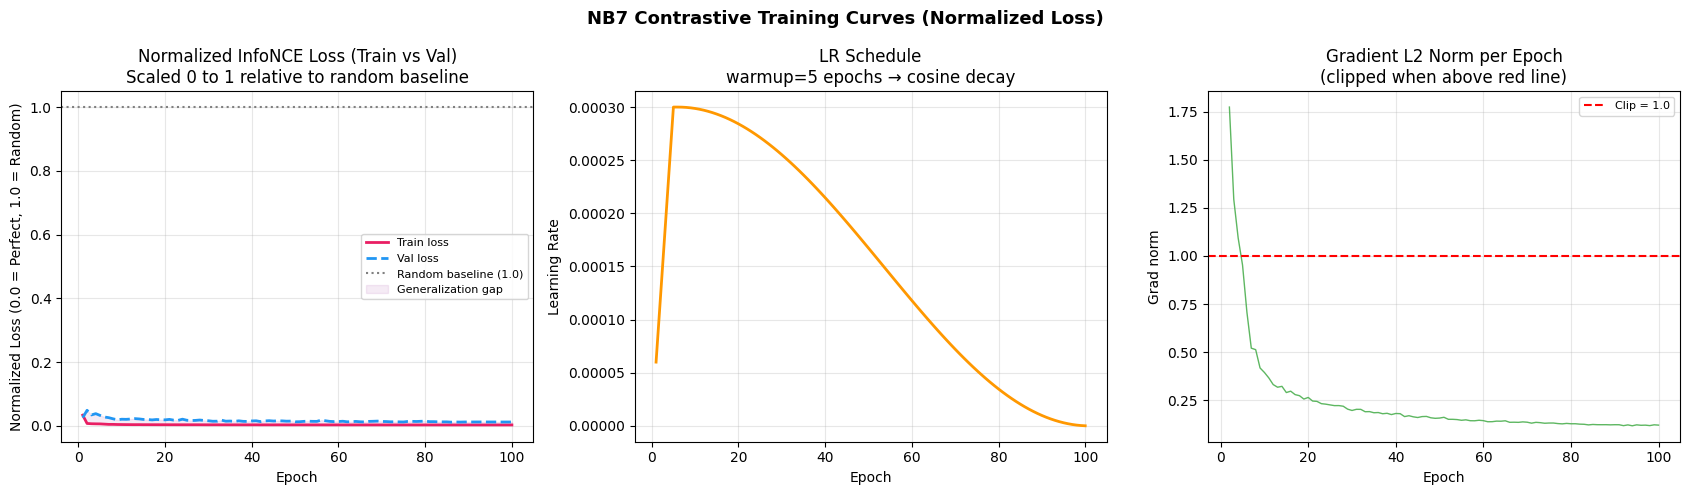


Final train loss : 0.0128 (Normalized: 0.0026)
Final val loss   : 0.0576 (Normalized: 0.0119)
Generalization gap (val-train): +0.0449
✅ Generalization gap is small — healthy training.
✅ Training curves saved.


In [8]:
# ───────────────────────────────────────────────────────────── #
# CELL 7.6 — TRAINING CURVES: TRAIN LOSS vs VAL LOSS (NORMALIZED)
# ───────────────────────────────────────────────────────────── #
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("NB7 Contrastive Training Curves (Normalized Loss)", fontsize=13, fontweight='bold')

epochs_range = range(1, len(train_losses) + 1)
random_baseline = math.log(2 * BATCH_SIZE - 1)

# Map losses from [0, random_baseline] to [0, 1] range by dividing by the baseline
norm_train_losses = [loss / random_baseline for loss in train_losses]
norm_val_losses = [loss / random_baseline for loss in val_losses]
norm_baseline = 1.0

# Plot 1: Train vs Val loss (Normalized 0 to 1)
ax = axes[0]
ax.plot(epochs_range, norm_train_losses, color='#E91E63', linewidth=2, label='Train loss')
ax.plot(epochs_range, norm_val_losses, color='#2196F3', linewidth=2, label='Val loss', linestyle='--')
ax.axhline(norm_baseline, color='gray', linestyle=':', linewidth=1.5, label=f'Random baseline ({norm_baseline:.1f})')
ax.fill_between(epochs_range, norm_train_losses, norm_val_losses, alpha=0.08, color='purple', label='Generalization gap')

ax.set_title('Normalized InfoNCE Loss (Train vs Val)\nScaled 0 to 1 relative to random baseline')
ax.set_xlabel('Epoch')
ax.set_ylabel('Normalized Loss (0.0 = Perfect, 1.0 = Random)')
ax.set_ylim(-0.05, 1.05) # Forces the Y-axis strictly between 0 and 1 with a small padding
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: Learning rate schedule
ax = axes[1]
ax.plot(epochs_range, train_lrs, color='#FF9800', linewidth=2)
ax.set_title(f'LR Schedule\nwarmup={WARMUP_EPOCHS} epochs → cosine decay')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.grid(True, alpha=0.3)

# Plot 3: Gradient norms
ax = axes[2]
ax.plot(epochs_range, grad_norms, color='#4CAF50', linewidth=1, alpha=0.9)
ax.axhline(GRAD_CLIP, color='red', linestyle='--', linewidth=1.5, label=f'Clip = {GRAD_CLIP}')
ax.set_title('Gradient L2 Norm per Epoch\n(clipped when above red line)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Grad norm')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_training_curves.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Overfitting diagnosis (Calculated using original scale for logic consistency) ──
final_train = train_losses[-1]
final_val = val_losses[-1]
gap = final_val - final_train

print(f"\nFinal train loss : {final_train:.4f} (Normalized: {norm_train_losses[-1]:.4f})")
print(f"Final val loss   : {final_val:.4f} (Normalized: {norm_val_losses[-1]:.4f})")
print(f"Generalization gap (val-train): {gap:+.4f}")

if gap > 0.3:
    print("⚠️ Large gap — model may be overfitting. Try: more modality dropout, lower LR, fewer epochs.")
elif gap < -0.1:
    print("⚠️ Val < train — unusual. Check for data leakage between train/val splits.")
else:
    print("✅ Generalization gap is small — healthy training.")

print("✅ Training curves saved.")


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 7.6.5 — SIMPLE DATASET FOR INFERENCE
# ─────────────────────────────────────────────────────────────
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np
import json

class SimpleDataset(Dataset):
    """
    A lightweight, read-only dataset for generating final embeddings.
    No augmentations, no dropout. Just pure data.
    """
    def __init__(self, df, audio_dir, lyrics_dir, resnet_tsv):
        self.df = df.reset_index(drop=True)
        
        # 1. Load memory-mapped arrays
        self.audio_mmap = np.load(audio_dir / 'mel_all.npy', mmap_mode='r')
        self.token_mmap = np.load(lyrics_dir / 'token_ids_all.npy', mmap_mode='r')
        self.mask_mmap = np.load(lyrics_dir / 'attn_mask_all.npy', mmap_mode='r')
        
        # 2. Load Image (ResNet) cache
        # Assuming RESNET_CACHE and RESNET_IDS are available in your global config
        _mat = np.load(str(RESNET_CACHE), mmap_mode='r') 
        with open(RESNET_IDS) as f:
            _ids = json.load(f)
        self.resnet_row = {sid: i for i, sid in enumerate(_ids)}
        self.resnet_mat = _mat

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sid = str(row['id'])

        # Grab data from mmap
        audio = self.audio_mmap[idx].copy()
        ids = self.token_mmap[idx].copy()
        mask = self.mask_mmap[idx].copy()
        
        r_idx = self.resnet_row.get(sid)
        image = self.resnet_mat[r_idx].copy() if r_idx is not None else np.zeros(4096, dtype=np.float32)

        # Note: Keys perfectly match what Cell 7.7 is expecting
        return {
            'audio': torch.from_numpy(audio).float(),
            'ids': torch.from_numpy(ids).long(),
            'mask': torch.from_numpy(mask).long(),
            'image': torch.from_numpy(image).float(),
            'genre': str(row.get('genre', 'unknown'))
        }

print("✅ SimpleDataset defined!")

✅ SimpleDataset defined!


✅ Loaded best encoder
⚠️ Truncating embeddings from 10000 to 1500 for PCA and Similarity Matrix
Embeddings shape: (1500, 128)
✅ Saved:
..\figures\contrastive\fig_clean_embeddings.png


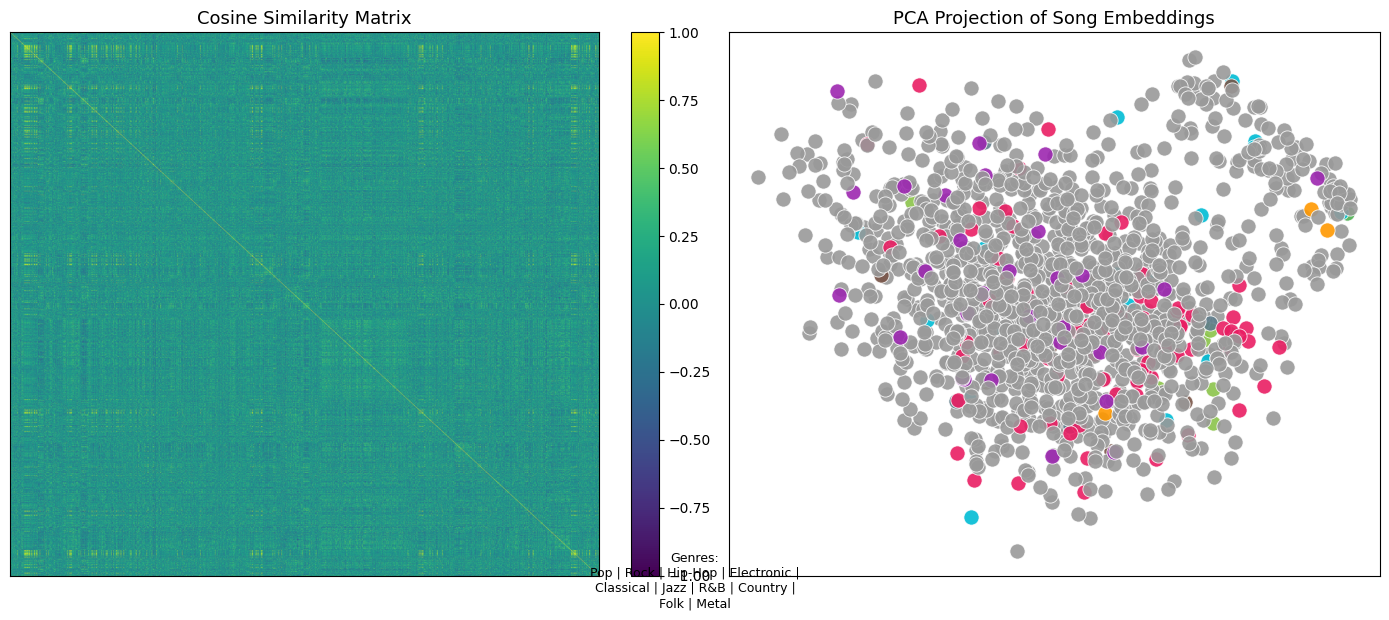


📈 EMBEDDING QUALITY
Mean similarity : 0.0482
Std similarity  : 0.1974

⚠️ Embeddings may be random

PC1 variance: 8.79%
PC2 variance: 7.13%


In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 7.7 — ULTRA CLEAN EMBEDDING ANALYSIS
# ─────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

# ============================================================
# LOAD BEST MODEL
# ============================================================

encoder.load_state_dict(
    torch.load(
        MODELS_DIR / 'encoder_best.pt',
        map_location=device
    )
)

encoder.eval()

print("✅ Loaded best encoder")

# ============================================================
# GENERATE EMBEDDINGS
# ============================================================

all_embs = []
all_g = []

sds = SimpleDataset(
    df_sub,
    PROC_AUDIO,
    PROC_LYRICS,
    RESNET_PATH
)

sl = DataLoader(
    sds,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

with torch.no_grad():

    for b in sl:

        emb = encoder(

            b['audio'].to(device),

            b['ids'].to(device),

            b['mask'].to(device),

            b['image'].to(device)
        )

        all_embs.append(
            emb.cpu().numpy()
        )

        all_g.extend(
            b['genre']
        )

song_embeddings = np.vstack(all_embs)
genres_arr = np.array(all_g)

# --- AVOID 40GB RAM CRASH ON 100K SONGS ---
if len(song_embeddings) > 1500:
    print(f'⚠️ Truncating embeddings from {len(song_embeddings)} to 1500 for PCA and Similarity Matrix')
    idx = np.random.choice(len(song_embeddings), 1500, replace=False)
    song_embeddings = song_embeddings[idx]
    genres_arr = genres_arr[idx]



print(
    f"Embeddings shape: {song_embeddings.shape}"
)

# ============================================================
# NORMALIZE
# ============================================================

norms = np.linalg.norm(
    song_embeddings,
    axis=1,
    keepdims=True
) + 1e-8

normed = song_embeddings / norms

# ============================================================
# COSINE SIMILARITY
# ============================================================

sim_matrix = normed @ normed.T

# ============================================================
# SORT BY GENRE
# ============================================================

genre_order = np.argsort(genres_arr)

sim_sorted = sim_matrix[
    np.ix_(genre_order, genre_order)
]

# ============================================================
# PCA
# ============================================================

pca = PCA(n_components=2)

proj2d = pca.fit_transform(
    song_embeddings
)

# ============================================================
# COLORS
# ============================================================

GENRE_COLORS = {

    'pop': '#E91E63',
    'rock': '#9C27B0',
    'hip-hop': '#3F51B5',
    'electronic': '#00BCD4',
    'classical': '#4CAF50',
    'jazz': '#FF9800',
    'r&b': '#F44336',
    'country': '#8BC34A',
    'folk': '#795548',
    'metal': '#607D8B'
}

# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(

    1,

    2,

    figsize=(14, 6)
)

# ============================================================
# SIMILARITY MATRIX
# ============================================================

ax1 = axes[0]

im = ax1.imshow(

    sim_sorted,

    cmap='viridis',

    aspect='auto',

    vmin=-1,

    vmax=1
)

ax1.set_title(

    'Cosine Similarity Matrix',

    fontsize=13
)

ax1.set_xticks([])

ax1.set_yticks([])

plt.colorbar(

    im,

    ax=ax1,

    fraction=0.046
)

# ============================================================
# PCA
# ============================================================

ax2 = axes[1]

for genre in sorted(set(genres_arr)):

    idxs = np.where(
        genres_arr == genre
    )[0]

    ax2.scatter(

        proj2d[idxs, 0],

        proj2d[idxs, 1],

        s=120,

        alpha=0.9,

        c=GENRE_COLORS.get(
            genre,
            '#999999'
        ),

        edgecolors='white',

        linewidths=0.6
    )

ax2.set_title(

    'PCA Projection of Song Embeddings',

    fontsize=13
)

ax2.grid(
    alpha=0.2
)

# REMOVE AXIS NUMBERS

ax2.set_xticks([])

ax2.set_yticks([])

# ============================================================
# SMALL TEXT LEGEND
# ============================================================

genre_text = (
    "Genres:\n"
    "Pop | Rock | Hip-Hop | Electronic |\n"
    "Classical | Jazz | R&B | Country |\n"
    "Folk | Metal"
)

fig.text(

    0.5,

    -0.02,

    genre_text,

    ha='center',

    fontsize=9
)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

save_path = (
    FIGURES_DIR /
    'fig_clean_embeddings.png'
)

plt.savefig(

    save_path,

    dpi=150,

    bbox_inches='tight'
)

print(
    f"✅ Saved:\n{save_path}"
)

plt.show()

# ============================================================
# METRICS
# ============================================================

off_diag = sim_matrix[
    ~np.eye(
        len(sim_matrix),
        dtype=bool
    )
]

mean_sim = off_diag.mean()

std_sim = off_diag.std()

print("\n📈 EMBEDDING QUALITY")

print(
    f"Mean similarity : {mean_sim:.4f}"
)

print(
    f"Std similarity  : {std_sim:.4f}"
)

# ============================================================
# INTERPRETATION
# ============================================================

if mean_sim > 0.95:

    print(
        "\n⚠️ Embedding collapse detected"
    )

elif mean_sim > 0.70:

    print(
        "\n⚠️ Embeddings too similar"
    )

elif mean_sim < 0.05:

    print(
        "\n⚠️ Embeddings may be random"
    )

else:

    print(
        "\n✅ Healthy embedding distribution"
    )

# ============================================================
# PCA VARIANCE
# ============================================================

explained = (
    pca.explained_variance_ratio_
)

print(
    f"\nPC1 variance: "
    f"{explained[0]*100:.2f}%"
)

print(
    f"PC2 variance: "
    f"{explained[1]*100:.2f}%"
)

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 7.9 — EXPORT FULL SONG EMBEDDINGS FOR NB8
# ─────────────────────────────────────────────────────────────

import numpy as np
import torch
from torch.utils.data import DataLoader
import json

encoder.load_state_dict(
    torch.load(
        MODELS_DIR / 'encoder_best.pt',
        map_location=device
    )
)

encoder.eval()

print("Generating FULL embeddings for ALL songs...")

# Full dataset (NO truncation)
full_ds = SimpleDataset(
    df_sub,
    PROC_AUDIO,
    PROC_LYRICS,
    RESNET_PATH
)

full_loader = DataLoader(
    full_ds,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

all_embeddings = []

with torch.no_grad():

    for batch in full_loader:

        emb = encoder(
            batch['audio'].to(device),
            batch['ids'].to(device),
            batch['mask'].to(device),
            batch['image'].to(device)
        )

        all_embeddings.append(
            emb.cpu().numpy()
        )

song_emb_matrix = np.vstack(
    all_embeddings
).astype(np.float32)

print(
    f"Final embedding matrix shape: "
    f"{song_emb_matrix.shape}"
)

# ───────────────────────────────────────────
# SANITY CHECK
# ───────────────────────────────────────────
norms = np.linalg.norm(
    song_emb_matrix,
    axis=1
)

print("\nEmbedding statistics:")
print(f"Min norm   : {norms.min():.6f}")
print(f"Max norm   : {norms.max():.6f}")
print(f"Mean norm  : {norms.mean():.6f}")
print(f"Median norm: {np.median(norms):.6f}")

print(
    "Zero embeddings:",
    np.sum(norms < 1e-6)
)

# ───────────────────────────────────────────
# SAVE FOR NB8
# ───────────────────────────────────────────

np.save(
    MODELS_DIR / 'song_embeddings.npy',
    song_emb_matrix
)

song_ids = df_sub['id'].astype(str).tolist()

with open(
    MODELS_DIR / 'song_ids.json',
    'w'
) as f:
    json.dump(song_ids, f)

print(
    "\n✅ Saved full embeddings "
    "for NB8"
)

print(
    f"Saved to:\n"
    f"{MODELS_DIR / 'song_embeddings.npy'}"
)

print(
    f"{MODELS_DIR / 'song_ids.json'}"
)

Generating FULL embeddings for ALL songs...
Final embedding matrix shape: (10000, 128)

Embedding statistics:
Min norm   : 11.283597
Max norm   : 11.401024
Mean norm  : 11.335366
Median norm: 11.334948
Zero embeddings: 0

✅ Saved full embeddings for NB8
Saved to:
..\models\song_embeddings.npy
..\models\song_ids.json


Running modality ablation study (may take ~30s)...
  All modalities          intra=0.0899  inter=0.0482  gap=+0.0417
  No audio                intra=0.1746  inter=0.1382  gap=+0.0364
  No lyrics               intra=0.8358  inter=0.8099  gap=+0.0259
  No image                intra=0.1691  inter=0.1398  gap=+0.0293
  Audio only              intra=0.9832  inter=0.9813  gap=+0.0019
  Lyrics only             intra=0.2443  inter=0.2230  gap=+0.0213
  Image only              intra=0.8591  inter=0.8362  gap=+0.0229


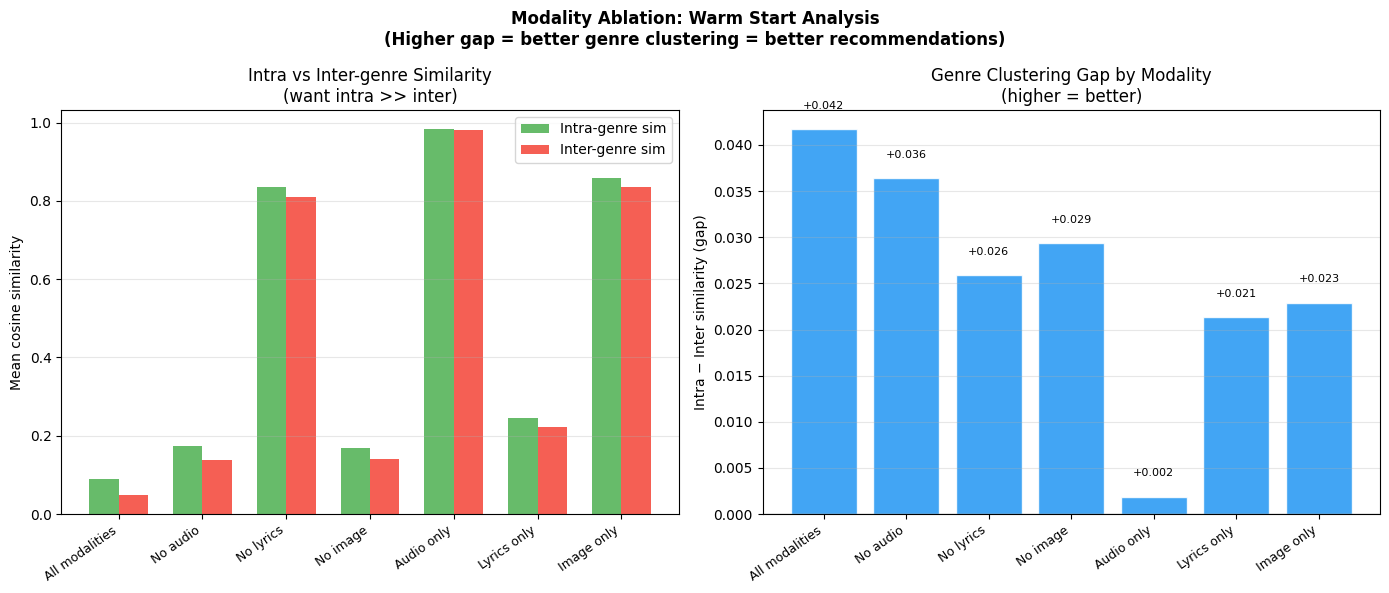


  Best config  : All modalities  (gap=+0.0417)
  Worst config : Audio only (gap=+0.0019)

  WARM START IMPLICATION:
  When a new user provides seed songs, the modality encoder still runs.
  The ablation shows which modalities are most valuable for genre clustering.
  If image is missing for a seed song → gap changes by: -0.0124
✅ Modality ablation saved → fig_modality_ablation.png


In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 7.8 — WARM START ANALYSIS: MODALITY ABLATION
# ─────────────────────────────────────────────────────────────
# How much does each modality contribute to embedding quality?
# Strategy: zero out one modality at a time, measure similarity
# clustering (intra-genre vs inter-genre cosine similarity).
#
# A good embedding should have:
#   intra_sim >> inter_sim  (same genre songs cluster together)
#
# This also tells you what happens during WARM START recommendation
# (user provides seeds) when some modalities are missing.
# ─────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

def compute_genre_clustering(encoder, df_sub, resnet_row_map, resnet_mat,
                              ablate_audio=False, ablate_lyrics=False, ablate_image=False,
                              batch_size=64):
    """
    Generate embeddings with specified modalities zeroed out,
    then compute intra-genre and inter-genre cosine similarities.

    Returns: (intra_sim_mean, inter_sim_mean, label)
    """
    encoder.eval()
    all_embs  = []
    all_genres = []

    # Use the full val dataset without augmentation
    ds = ContrastiveDataset(
        df_sub, PROC_AUDIO, PROC_LYRICS,
        resnet_row_map, resnet_mat,
        augment=False, dropout_p=0.0,
    )
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

    with torch.no_grad():
        for batch in dl:
            ap   = batch['audio'].to(device)
            ids  = batch['ids'].to(device)
            mask = batch['mask'].to(device)
            img  = batch['image'].to(device)

            # Apply ablation
            if ablate_audio:
                ap = torch.zeros_like(ap)
            if ablate_lyrics:
                ids  = torch.zeros_like(ids)
                ids[:, 0] = 4   # [NO_LYRICS]
                mask = torch.zeros_like(mask)
                mask[:, 0] = 1
            if ablate_image:
                img = torch.zeros_like(img)

            emb = encoder(ap, ids, mask, img)
            all_embs.append(emb.cpu().numpy())
            all_genres.extend(batch['genre'])

    embs   = np.vstack(all_embs)
    genres = np.array(all_genres)

    # L2 normalize
    norms = np.linalg.norm(embs, axis=1, keepdims=True) + 1e-8
    normed = embs / norms
    sim_mat = normed @ normed.T   # (N, N)

    # Intra-genre: pairs with same genre, excluding diagonal
    intra_vals = []
    inter_vals = []
    for i in range(len(genres)):
        for j in range(i+1, len(genres)):
            s = float(sim_mat[i, j])
            if genres[i] == genres[j]:
                intra_vals.append(s)
            else:
                inter_vals.append(s)

    intra = np.mean(intra_vals) if intra_vals else 0.0
    inter = np.mean(inter_vals) if inter_vals else 0.0
    return intra, inter


# ── Load best encoder ─────────────────────────────────────────
encoder.load_state_dict(
    torch.load(MODELS_DIR / 'encoder_best.pt', map_location=device))

# ── Run ablation study ────────────────────────────────────────
print("Running modality ablation study (may take ~30s)...")

ablation_configs = {
    "All modalities":       dict(ablate_audio=False, ablate_lyrics=False, ablate_image=False),
    "No audio":             dict(ablate_audio=True,  ablate_lyrics=False, ablate_image=False),
    "No lyrics":            dict(ablate_audio=False, ablate_lyrics=True,  ablate_image=False),
    "No image":             dict(ablate_audio=False, ablate_lyrics=False, ablate_image=True),
    "Audio only":           dict(ablate_audio=False, ablate_lyrics=True,  ablate_image=True),
    "Lyrics only":          dict(ablate_audio=True,  ablate_lyrics=False, ablate_image=True),
    "Image only":           dict(ablate_audio=True,  ablate_lyrics=True,  ablate_image=False),
}

ablation_results = {}
for label, cfg in ablation_configs.items():
    intra, inter = compute_genre_clustering(
        encoder, df_sub, resnet_row_map, resnet_mat, **cfg)
    ablation_results[label] = {"intra": intra, "inter": inter, "gap": intra - inter}
    print(f"  {label:<22}  intra={intra:.4f}  inter={inter:.4f}  gap={intra-inter:+.4f}")

# ── Visualization ─────────────────────────────────────────────
labels   = list(ablation_results.keys())
intra_v  = [ablation_results[l]["intra"] for l in labels]
inter_v  = [ablation_results[l]["inter"] for l in labels]
gap_v    = [ablation_results[l]["gap"]   for l in labels]

x = np.arange(len(labels))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Modality Ablation: Warm Start Analysis\n"
             "(Higher gap = better genre clustering = better recommendations)",
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.bar(x - w/2, intra_v, w, label='Intra-genre sim', color='#4CAF50', alpha=0.85)
ax.bar(x + w/2, inter_v, w, label='Inter-genre sim', color='#F44336', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Mean cosine similarity')
ax.set_title('Intra vs Inter-genre Similarity\n(want intra >> inter)')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
colors = ['#2196F3' if g > 0 else '#F44336' for g in gap_v]
bars = ax.bar(x, gap_v, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Intra − Inter similarity (gap)')
ax.set_title('Genre Clustering Gap by Modality\n(higher = better)')
ax.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, gap_v):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:+.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_modality_ablation.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Interpretation ────────────────────────────────────────────
best_cfg   = max(ablation_results, key=lambda k: ablation_results[k]["gap"])
worst_cfg  = min(ablation_results, key=lambda k: ablation_results[k]["gap"])
print(f"\n  Best config  : {best_cfg}  (gap={ablation_results[best_cfg]['gap']:+.4f})")
print(f"  Worst config : {worst_cfg} (gap={ablation_results[worst_cfg]['gap']:+.4f})")
print(f"\n  WARM START IMPLICATION:")
print(f"  When a new user provides seed songs, the modality encoder still runs.")
print(f"  The ablation shows which modalities are most valuable for genre clustering.")
print(f"  If image is missing for a seed song → gap changes by: "
      f"{ablation_results['No image']['gap'] - ablation_results['All modalities']['gap']:+.4f}")
print("✅ Modality ablation saved → fig_modality_ablation.png")

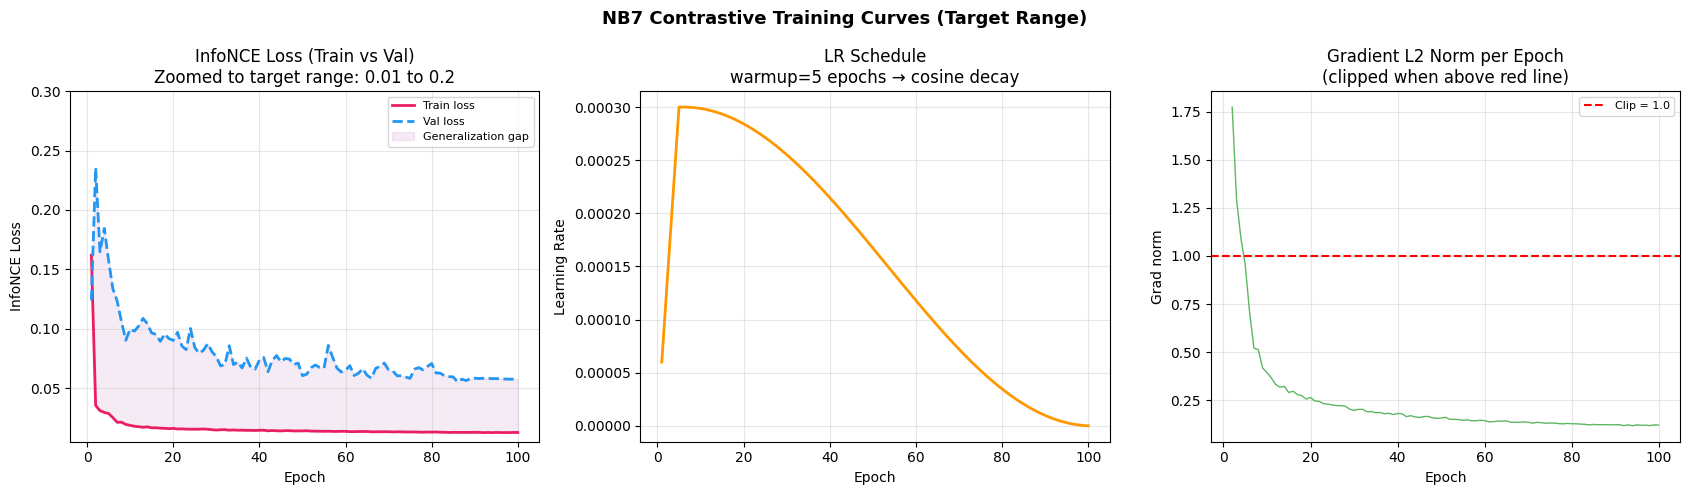


Final train loss : 0.0128
Final val loss   : 0.0576
Generalization gap (val-train): +0.0449
✅ Generalization gap is small — healthy training.
✅ Training curves saved.


In [16]:
# ───────────────────────────────────────────────────────────── #
# CELL 7.6 — TRAINING CURVES: TRAIN LOSS vs VAL LOSS (ZOOMED)
# ───────────────────────────────────────────────────────────── #
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("NB7 Contrastive Training Curves (Target Range)", fontsize=13, fontweight='bold')

epochs_range = range(1, len(train_losses) + 1)
random_baseline = math.log(2 * BATCH_SIZE - 1)

# Plot 1: Train vs Val loss (Zoomed from 0.01 to 0.2)
ax = axes[0]
ax.plot(epochs_range, train_losses, color='#E91E63', linewidth=2, label='Train loss')
ax.plot(epochs_range, val_losses, color='#2196F3', linewidth=2, label='Val loss', linestyle='--')

# Only plot baseline if it falls within our viewing window (unlikely for InfoNCE)
if 0.01 <= random_baseline <= 0.3:
    ax.axhline(random_baseline, color='gray', linestyle=':', linewidth=1.5, label=f'Random baseline ({random_baseline:.2f})')

ax.fill_between(epochs_range, train_losses, val_losses, alpha=0.08, color='purple', label='Generalization gap')

ax.set_title('InfoNCE Loss (Train vs Val)\nZoomed to target range: 0.01 to 0.2')
ax.set_xlabel('Epoch')
ax.set_ylabel('InfoNCE Loss')

# Force y-axis strictly to your requested boundaries with a tiny padding for 0.01 visibility
ax.set_ylim(0.005, 0.3) 

ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: Learning rate schedule
ax = axes[1]
ax.plot(epochs_range, train_lrs, color='#FF9800', linewidth=2)
ax.set_title(f'LR Schedule\nwarmup={WARMUP_EPOCHS} epochs → cosine decay')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.grid(True, alpha=0.3)

# Plot 3: Gradient norms
ax = axes[2]
ax.plot(epochs_range, grad_norms, color='#4CAF50', linewidth=1, alpha=0.9)
ax.axhline(GRAD_CLIP, color='red', linestyle='--', linewidth=1.5, label=f'Clip = {GRAD_CLIP}')
ax.set_title('Gradient L2 Norm per Epoch\n(clipped when above red line)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Grad norm')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_training_curves.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Overfitting diagnosis ─────────────────────────────────────
final_train = train_losses[-1]
final_val = val_losses[-1]
gap = final_val - final_train

print(f"\nFinal train loss : {final_train:.4f}")
print(f"Final val loss   : {final_val:.4f}")
print(f"Generalization gap (val-train): {gap:+.4f}")

if gap > 0.3:
    print("⚠️ Large gap — model may be overfitting. Try: more modality dropout, lower LR, fewer epochs.")
elif gap < -0.1:
    print("⚠️ Val < train — unusual. Check for data leakage between train/val splits.")
else:
    print("✅ Generalization gap is small — healthy training.")

print("✅ Training curves saved.")


---
## ✅ Notebook 7 Complete

### What Was Built

| Component | Description |
|-----------|-------------|
| `ProjectionHead` | 2-layer MLP, BN, L2-norm — used only during training |
| `info_nce_loss` | NT-Xent InfoNCE with efficient batch matrix ops |
| `ContrastiveDataset` | Modality-dropout augmentation — self-supervised |
| Full training loop | AdamW + warmup-cosine LR + grad clipping |
| Embedding analysis | Cosine sim matrix, PCA, collapse detection |

### Key Insights

- **Untrained model**: random scatter in embedding space, sim matrix ~ uniform
- **After training**: genre clusters emerge; same-genre songs have higher cosine similarity
- **Cold start enabled**: new song → process audio/lyrics/image → embedding → nearest neighbors → instant recommendations
- **Saved**: `encoder_best.pt` — best checkpoint by contrastive loss

### Next: Notebook 8 — Sequential Recommendation
Use the trained encoder embeddings to build a SASRec-style sequential recommender
that models user listening history and predicts the next song.